In [1]:
# ============================================
# STEP 1 — Environment Setup & Dataset Loading
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression

# Settings
pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

# Load Dataset
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nDataset Info:")
print(df.info())

Dataset Shape: (1460, 81)

First 5 Rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64 

In [2]:
# ==================================================
# STEP 2 — Numerical & Categorical Feature Analysis
# ==================================================

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Number of Numerical Columns:", len(numerical_cols))
print("Number of Categorical Columns:", len(categorical_cols))

print("\nSample Numerical Columns:")
print(numerical_cols[:10])

print("\nSample Categorical Columns:")
print(categorical_cols[:10])

Number of Numerical Columns: 38
Number of Categorical Columns: 43

Sample Numerical Columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']

Sample Categorical Columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']


SalePrice Statistics:

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


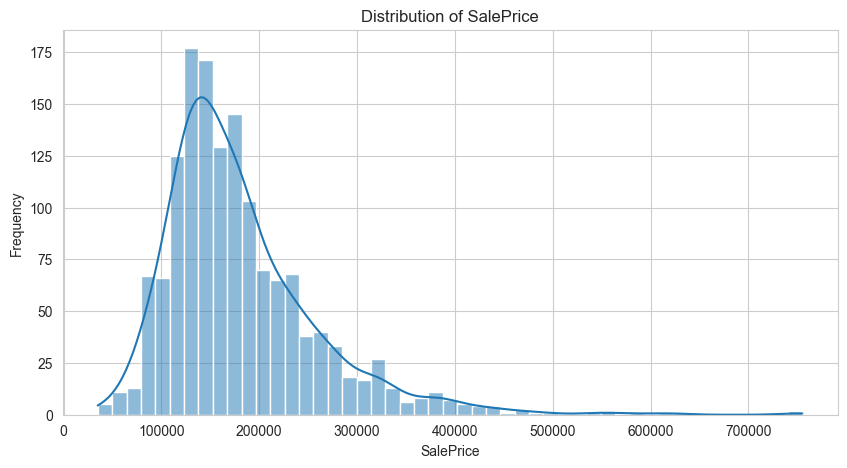

In [3]:
# ============================================
# STEP 3 — Target Variable Analysis
# ============================================

print("SalePrice Statistics:\n")
print(df['SalePrice'].describe())

plt.figure(figsize=(10,5))

sns.histplot(df['SalePrice'], kde=True)

plt.title("Distribution of SalePrice")

plt.xlabel("SalePrice")

plt.ylabel("Frequency")

plt.show()

              Missing Values  Percentage
PoolQC                  1453   99.520548
MiscFeature             1406   96.301370
Alley                   1369   93.767123
Fence                   1179   80.753425
MasVnrType               872   59.726027
FireplaceQu              690   47.260274
LotFrontage              259   17.739726
GarageType                81    5.547945
GarageYrBlt               81    5.547945
GarageFinish              81    5.547945
GarageQual                81    5.547945
GarageCond                81    5.547945
BsmtExposure              38    2.602740
BsmtFinType2              38    2.602740
BsmtQual                  37    2.534247
BsmtCond                  37    2.534247
BsmtFinType1              37    2.534247
MasVnrArea                 8    0.547945
Electrical                 1    0.068493


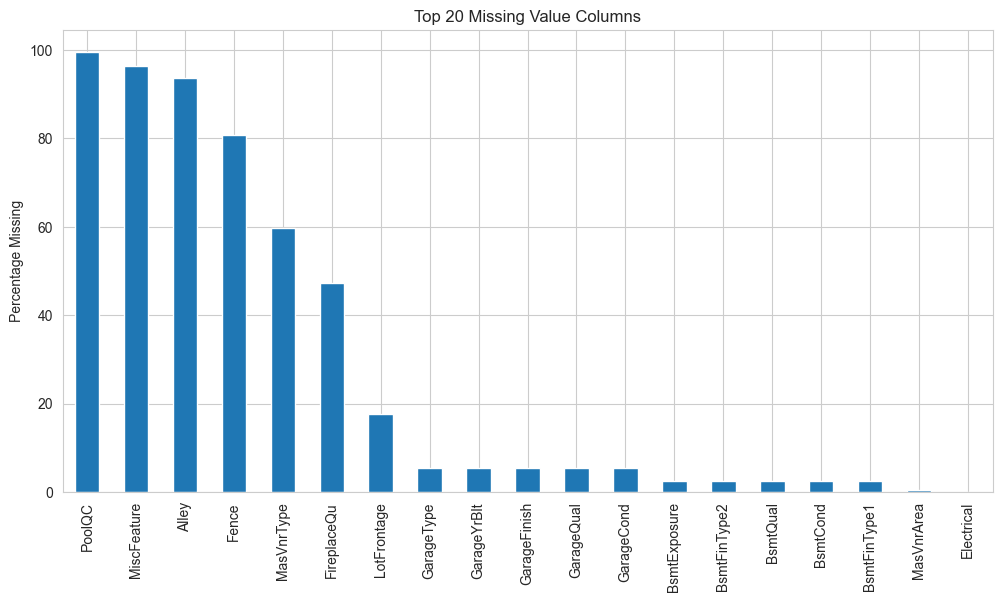

In [4]:
# ============================================
# STEP 4 — Missing Value Analysis
# ============================================

missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing,
    'Percentage': missing_percent
})

print(missing_df.head(20))

plt.figure(figsize=(12,6))

missing_percent.head(20).plot(kind='bar')

plt.title("Top 20 Missing Value Columns")

plt.ylabel("Percentage Missing")

plt.show()

Top Positive Correlations:

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64

Top Negative Correlations:

BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


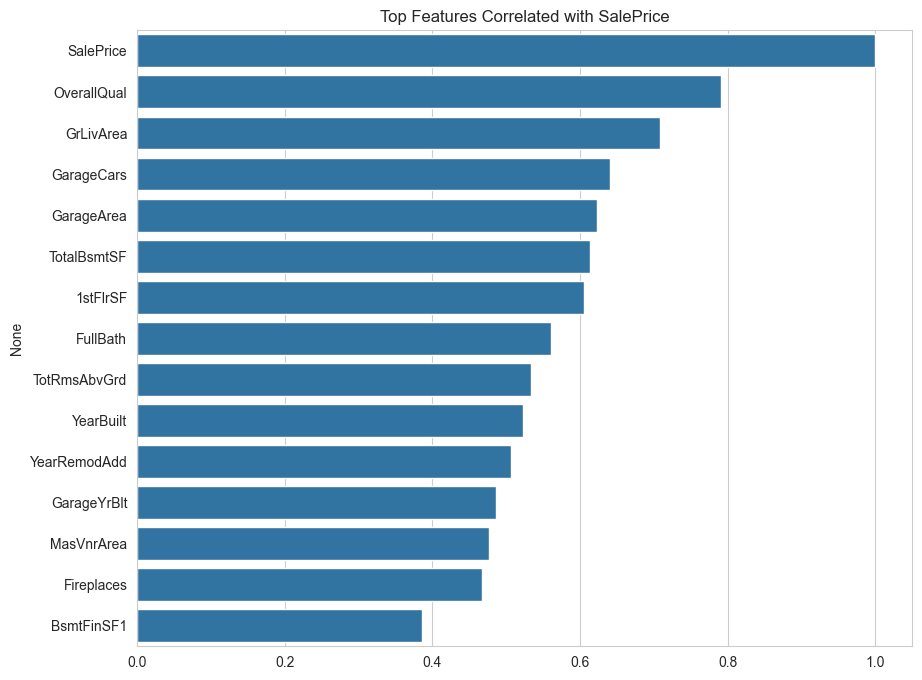

In [5]:
# ============================================
# STEP 5 — Correlation with SalePrice
# ============================================

numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

saleprice_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

print("Top Positive Correlations:\n")
print(saleprice_corr.head(10))

print("\nTop Negative Correlations:\n")
print(saleprice_corr.tail(10))

plt.figure(figsize=(10,8))

top_corr = saleprice_corr.head(15)

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with SalePrice")

plt.show()

In [6]:
# ============================================
# STEP 6 — Missing Value Handling
# ============================================

# Fill Numerical Missing Values with Median
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    
    df[col] = df[col].fillna(df[col].median())

# Fill Categorical Missing Values with Mode
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    
    df[col] = df[col].fillna(df[col].mode()[0])

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


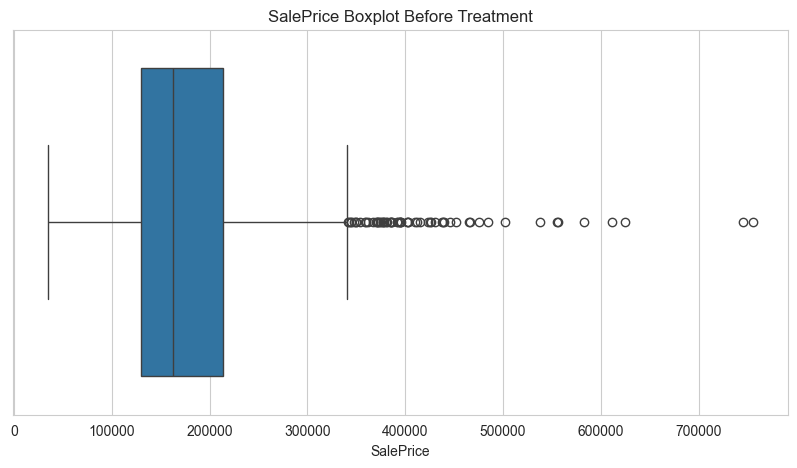

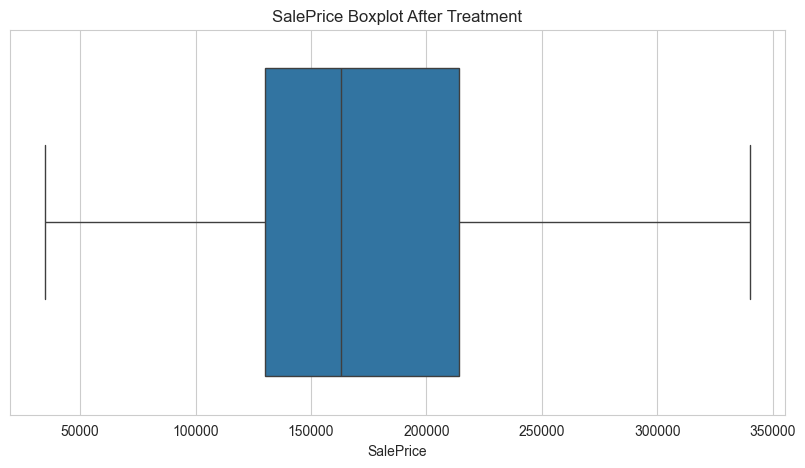

In [7]:
# ============================================
# STEP 7 — Outlier Detection & Treatment
# ============================================

plt.figure(figsize=(10,5))

sns.boxplot(x=df['SalePrice'])

plt.title("SalePrice Boxplot Before Treatment")

plt.show()

# IQR Method
Q1 = df['SalePrice'].quantile(0.25)

Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

# Cap Outliers
df['SalePrice'] = np.where(
    df['SalePrice'] > upper,
    upper,
    df['SalePrice']
)

plt.figure(figsize=(10,5))

sns.boxplot(x=df['SalePrice'])

plt.title("SalePrice Boxplot After Treatment")

plt.show()

In [8]:
# ============================================
# STEP 8 — Feature Engineering
# ============================================

# Total Bathrooms
df['TotalBathrooms'] = (
    df['FullBath']
    + (0.5 * df['HalfBath'])
    + df['BsmtFullBath']
    + (0.5 * df['BsmtHalfBath'])
)

# House Age
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Remodel Age
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

# Total Porch SF
df['TotalPorchSF'] = (
    df['OpenPorchSF']
    + df['3SsnPorch']
    + df['EnclosedPorch']
    + df['ScreenPorch']
    + df['WoodDeckSF']
)

# Total Living Area
df['TotalLivingArea'] = (
    df['GrLivArea']
    + df['TotalBsmtSF']
)

# Has Garage
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

# Has Basement
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

# Total Outdoor Area
df['TotalOutdoorArea'] = (
    df['LotArea']
    + df['TotalPorchSF']
)

engineered_features = [
    'TotalBathrooms',
    'HouseAge',
    'RemodelAge',
    'TotalPorchSF',
    'TotalLivingArea',
    'HasGarage',
    'HasBasement',
    'TotalOutdoorArea'
]

print("Engineered Features Created:\n")

for feature in engineered_features:
    print(feature)

Engineered Features Created:

TotalBathrooms
HouseAge
RemodelAge
TotalPorchSF
TotalLivingArea
HasGarage
HasBasement
TotalOutdoorArea


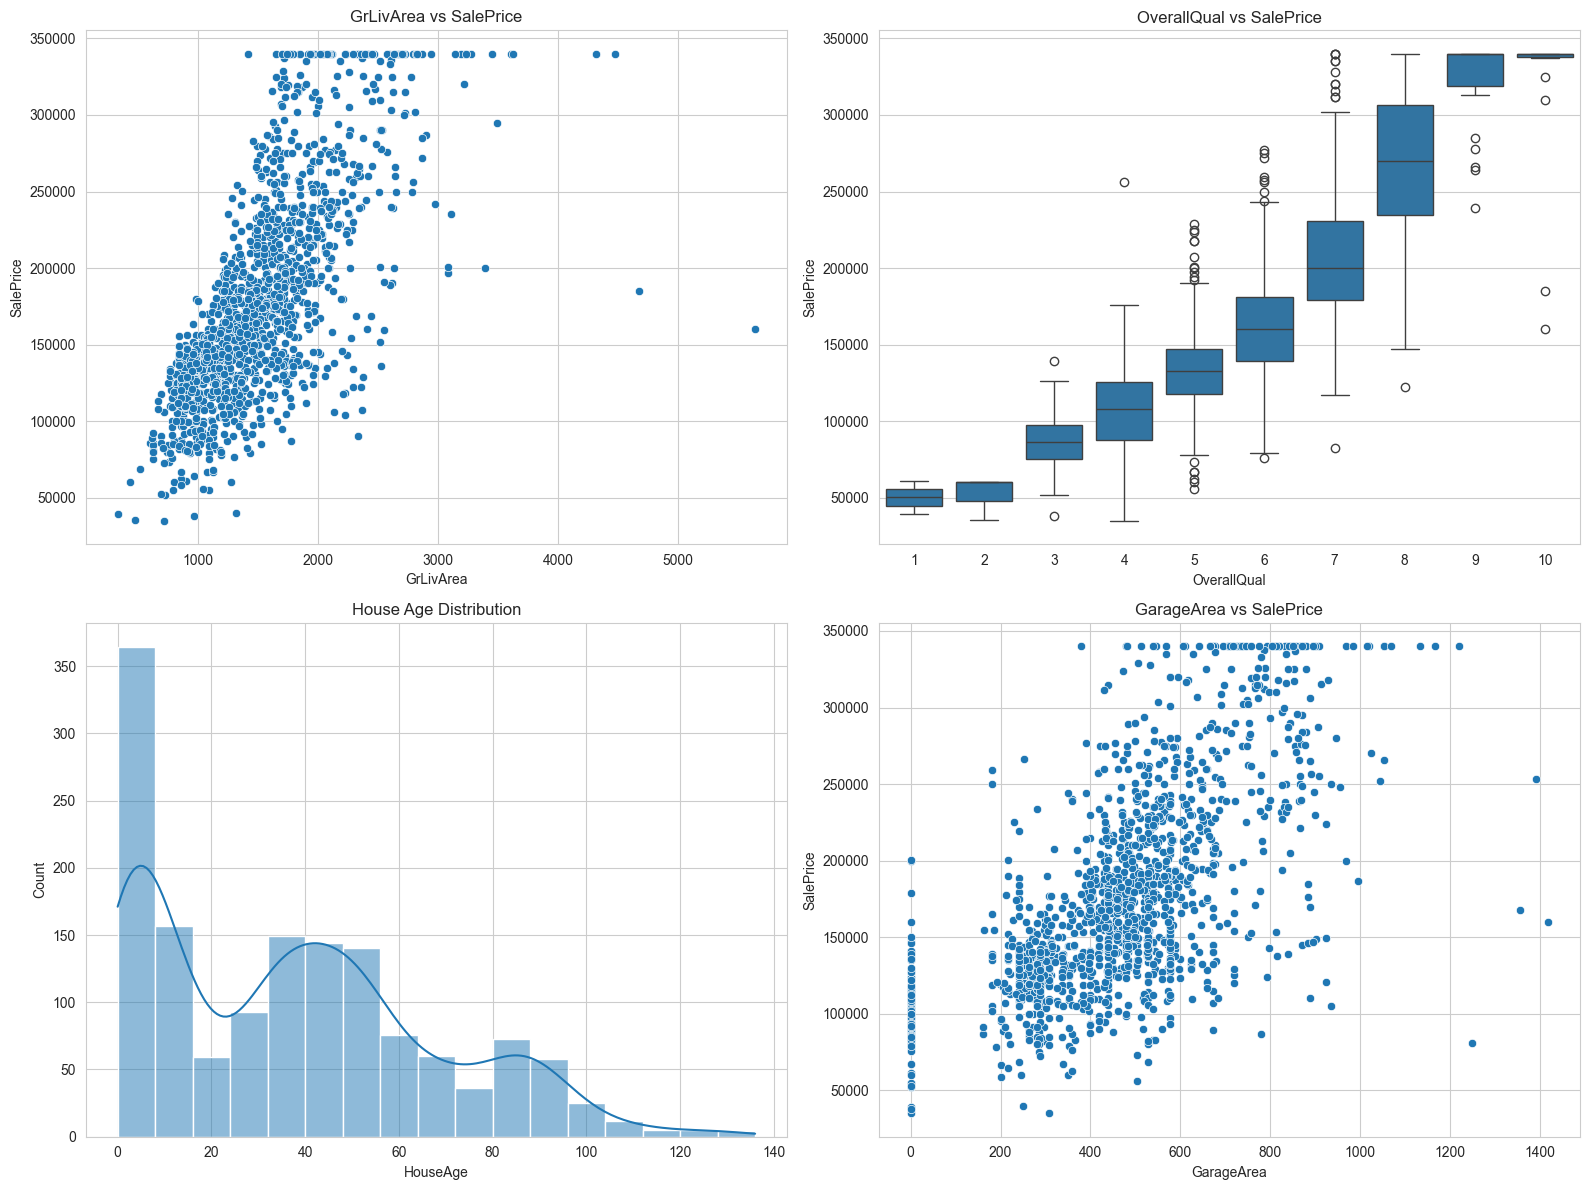

In [9]:
# ============================================
# STEP 9 — Feature Visualization
# ============================================

fig, axes = plt.subplots(2,2, figsize=(16,12))

sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice'],
    ax=axes[0,0]
)

axes[0,0].set_title("GrLivArea vs SalePrice")

sns.boxplot(
    x=df['OverallQual'],
    y=df['SalePrice'],
    ax=axes[0,1]
)

axes[0,1].set_title("OverallQual vs SalePrice")

sns.histplot(
    df['HouseAge'],
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("House Age Distribution")

sns.scatterplot(
    x=df['GarageArea'],
    y=df['SalePrice'],
    ax=axes[1,1]
)

axes[1,1].set_title("GarageArea vs SalePrice")

plt.tight_layout()

plt.savefig("feature_visualizations.png")

plt.show()

In [10]:
# ============================================
# STEP 10 — Encoding Categorical Features
# ============================================

# Copy dataset
encoded_df = df.copy()

# Label Encoding
label_encoders = {}

categorical_cols = encoded_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    
    le = LabelEncoder()
    
    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))
    
    label_encoders[col] = le

print("Encoding Completed")

display(encoded_df.head())

Encoding Completed


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,HouseAge,RemodelAge,TotalPorchSF,TotalLivingArea,HasGarage,HasBasement,TotalOutdoorArea
0,1,60,3,65.0,8450,1,0,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,1,196.0,2,4,2,2,3,3,2,706,5,0,150,856,1,0,1,4,856,854,0,1710,1,0,2,1,3,1,2,8,6,0,2,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,2,2,2,0,2,2008,8,4,208500.0,3.5,5,5,61,2566,1,1,8511
1,2,20,3,80.0,9600,1,0,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,1,0.0,3,4,1,2,3,1,0,978,5,0,284,1262,1,0,1,4,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,4,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,2,2,2,0,5,2007,8,4,181500.0,2.5,31,31,298,2524,1,1,9898
2,3,60,3,68.0,11250,1,0,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,1,162.0,2,4,2,2,3,2,2,486,5,0,434,920,1,0,1,4,920,866,0,1786,1,0,2,1,3,1,2,6,6,1,4,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,2,2,2,0,9,2008,8,4,223500.0,3.5,7,6,42,2706,1,1,11292
3,4,70,3,60.0,9550,1,0,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,1,0.0,3,4,0,3,1,3,0,216,5,0,540,756,1,2,1,4,961,756,0,1717,1,0,1,0,3,1,2,7,6,1,2,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,2,2,2,0,2,2006,8,0,140000.0,2.0,91,36,307,2473,1,1,9857
4,5,60,3,84.0,14260,1,0,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,1,350.0,2,4,2,2,3,0,2,655,5,0,490,1145,1,0,1,4,1145,1053,0,2198,1,0,2,1,4,1,2,9,6,1,4,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,2,2,2,0,12,2008,8,4,250000.0,3.5,8,8,276,3343,1,1,14536


In [11]:
# ============================================
# STEP 11 — Feature Scaling
# ============================================

scaled_df = encoded_df.copy()

numeric_cols = scaled_df.select_dtypes(include=['number']).columns.tolist()

# Remove target
numeric_cols.remove('SalePrice')

scaler = StandardScaler()

scaled_df[numeric_cols] = scaler.fit_transform(
    scaled_df[numeric_cols]
)

print("Scaling Completed")

display(scaled_df.head())

Scaling Completed


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,HouseAge,RemodelAge,TotalPorchSF,TotalLivingArea,HasGarage,HasBasement,TotalOutdoorArea
0,-1.730865,0.073375,-0.045532,-0.220875,-0.207142,0.064238,-0.169981,0.750731,0.314667,-0.02618,0.604670,-0.225716,-1.206215,-0.036289,-0.03174,-0.411691,1.026689,0.651479,-0.517200,1.050994,0.878668,-0.491516,-0.125797,0.743092,0.751626,-0.255234,0.514104,-0.777976,0.364207,0.835599,-0.324152,0.281048,0.628912,-0.429918,0.575425,0.307315,-0.288653,-0.944591,-0.459303,-0.123046,-0.884658,0.263813,0.302403,-0.793434,1.161852,-0.120242,0.370333,1.107810,-0.241061,0.789741,1.227585,0.163779,-0.211454,-0.409369,0.912210,0.255978,-0.951226,-0.430030,-0.686776,1.017598,-0.281887,0.311725,0.351000,0.215646,0.186019,0.289745,-0.752176,0.216503,-0.359325,-0.116339,-0.270208,-0.068692,0.049718,0.250362,0.039485,-0.087688,-1.599111,0.138777,0.313867,0.208502,208500.0,1.642256,-1.043259,-0.869941,-0.768375,-0.008372,0.24236,0.16125,-0.218540
1,-1.728492,-0.872563,-0.045532,0.460320,-0.091886,0.064238,-0.169981,0.750731,0.314667,-0.02618,-0.628316,-0.225716,1.954302,-1.188074,-0.03174,-0.411691,-0.543457,-0.071836,2.179628,0.156734,-0.429577,-0.491516,-0.125797,-0.508251,-0.661060,-0.255234,-0.570750,0.663451,0.364207,-0.549162,-0.324152,0.281048,-1.128430,-1.518697,1.171992,0.307315,-0.288653,-0.641228,0.466465,-0.123046,-0.884658,0.263813,0.302403,0.257140,-0.795163,-0.120242,-0.482512,-0.819964,3.948809,0.789741,-0.761621,0.163779,-0.211454,0.795629,-0.318683,0.255978,0.600495,1.792425,-0.686776,-0.107927,-0.281887,0.311725,-0.060731,0.215646,0.186019,0.289745,1.626195,-0.704483,-0.359325,-0.116339,-0.270208,-0.068692,0.049718,0.250362,0.039485,-0.087688,-0.489110,-0.614439,0.313867,0.208502,181500.0,0.368581,-0.183465,0.390141,0.745011,-0.059386,0.24236,0.16125,-0.079951
2,-1.726120,0.073375,-0.045532,-0.084636,0.073480,0.064238,-0.169981,-1.378933,0.314667,-0.02618,0.604670,-0.225716,-1.206215,-0.036289,-0.03174,-0.411691,1.026689,0.651479,-0.517200,0.984752,0.830215,-0.491516,-0.125797,0.743092,0.751626,-0.255234,0.325915,-0.777976,0.364207,0.835599,-0.324152,0.281048,-0.249759,-0.429918,0.092907,0.307315,-0.288653,-0.301643,-0.313369,-0.123046,-0.884658,0.263813,0.302403,-0.627826,1.189351,-0.120242,0.515013,1.107810,-0.241061,0.789741,1.227585,0.163779,-0.211454,-0.409369,-0.318683,0.255978,0.600495,1.792425,-0.686776,0.934226,-0.281887,0.311725,0.631726,0.215646,0.186019,0.289745,-0.752176,-0.070361,-0.359325,-0.116339,-0.270208,-0.068692,0.049718,0.250362,0.039485,-0.087688,0.990891,0.138777,0.313867,0.208502,223500.0,1.642256,-0.977121,-0.821476,-0.889702,0.161672,0.24236,0.16125,0.059337
3,-1.723747,0.309859,-0.045532,-0.447940,-0.096897,0.064238,-0.169981,-1.378933,0.314667,-0.02618,-1.861302,-0.225716,-1.039872,-0.036289,-0.03174,-0.411691,1.026689,0.651479,-0.517200,-1.863632,-0.720298,-0.491516,-0.125797,1.055928,1.316701,-0.255234,-0.570750,0.663451,0.364207,-1.933923,0.832969,-2.792584,0.628912,-1.518697,-0.499274,0.307315,-0.288653,-0.061670,-0.687324,-0.123046,0.265476,0.263813,0.302403,-0.521734,0.937276,-0.120242,0.383659,1.107810,-0.241061,-1.026041,-0.761621,0.163779,-0.2114

In [12]:
# ============================================
# STEP 12 — Skewness Analysis
# ============================================

skewness = scaled_df[numeric_cols].skew()

high_skew = skewness[abs(skewness) > 1]

print("Highly Skewed Features:\n")

print(high_skew.sort_values(ascending=False))

# Apply log transformation
for col in high_skew.index:
    
    scaled_df[col] = np.log1p(
        scaled_df[col] - scaled_df[col].min() + 1
    )

print("\nSkewness Treatment Completed")

Highly Skewed Features:

Utilities           38.209946
MiscVal             24.476794
PoolArea            14.828374
Condition2          13.171844
LotArea             12.207688
TotalOutdoorArea    12.120550
3SsnPorch           10.304342
Heating              9.855100
LowQualFinSF         9.011341
RoofMatl             8.109402
Alley                5.718902
LandSlope            4.813682
KitchenAbvGr         4.488397
BsmtFinSF2           4.255261
ScreenPorch          4.122214
BsmtHalfBath         4.103403
EnclosedPorch        3.089872
Condition1           3.019196
MasVnrArea           2.677616
LotFrontage          2.409147
OpenPorchSF          2.364342
BldgType             2.245648
MasVnrType           1.995364
TotalLivingArea      1.778029
BsmtFinSF1           1.685503
WoodDeckSF           1.541376
TotalBsmtSF          1.524255
RoofStyle            1.473796
MSSubClass           1.407657
1stFlrSF             1.376757
GrLivArea            1.366560
TotalPorchSF         1.102313
LotConfig      

            Feature  MI Score
84  TotalLivingArea  0.650606
17      OverallQual  0.564228
12     Neighborhood  0.533759
46        GrLivArea  0.471493
62       GarageArea  0.368322
61       GarageCars  0.357504
38      TotalBsmtSF  0.355899
19        YearBuilt  0.352750
80   TotalBathrooms  0.350865
53      KitchenQual  0.337161
81         HouseAge  0.335777
27        ExterQual  0.326918
30         BsmtQual  0.304804
59      GarageYrBlt  0.301832
43         1stFlrSF  0.296139


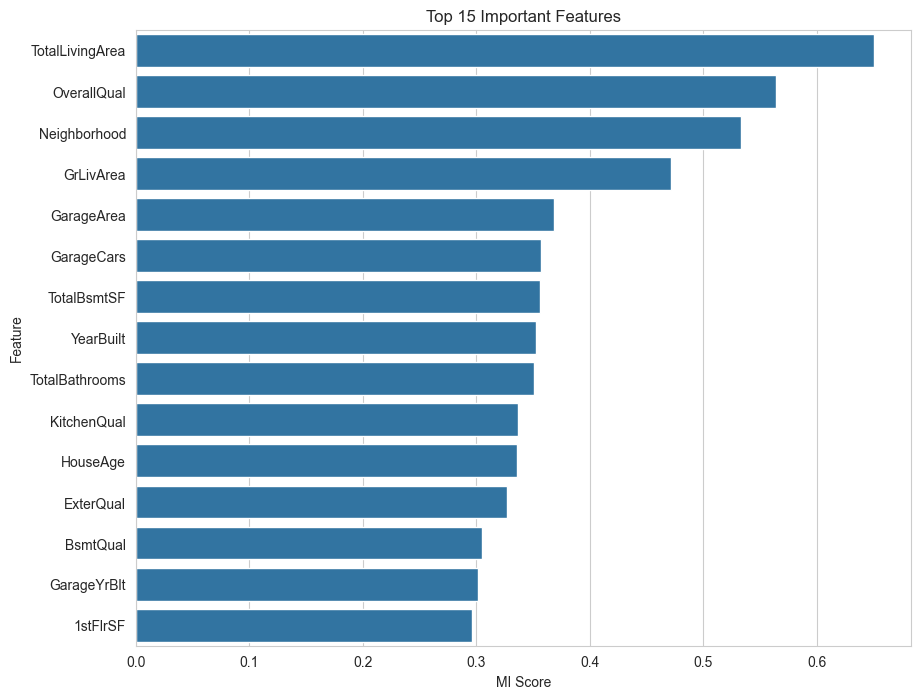

In [13]:
# ============================================
# STEP 13 — Feature Importance Analysis
# ============================================

X = scaled_df.drop(columns=['SalePrice'])

y = scaled_df['SalePrice']

mi_scores = mutual_info_regression(X, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
})

mi_df = mi_df.sort_values(
    by='MI Score',
    ascending=False
)

print(mi_df.head(15))

plt.figure(figsize=(10,8))

sns.barplot(
    x=mi_df.head(15)['MI Score'],
    y=mi_df.head(15)['Feature']
)

plt.title("Top 15 Important Features")

plt.show()

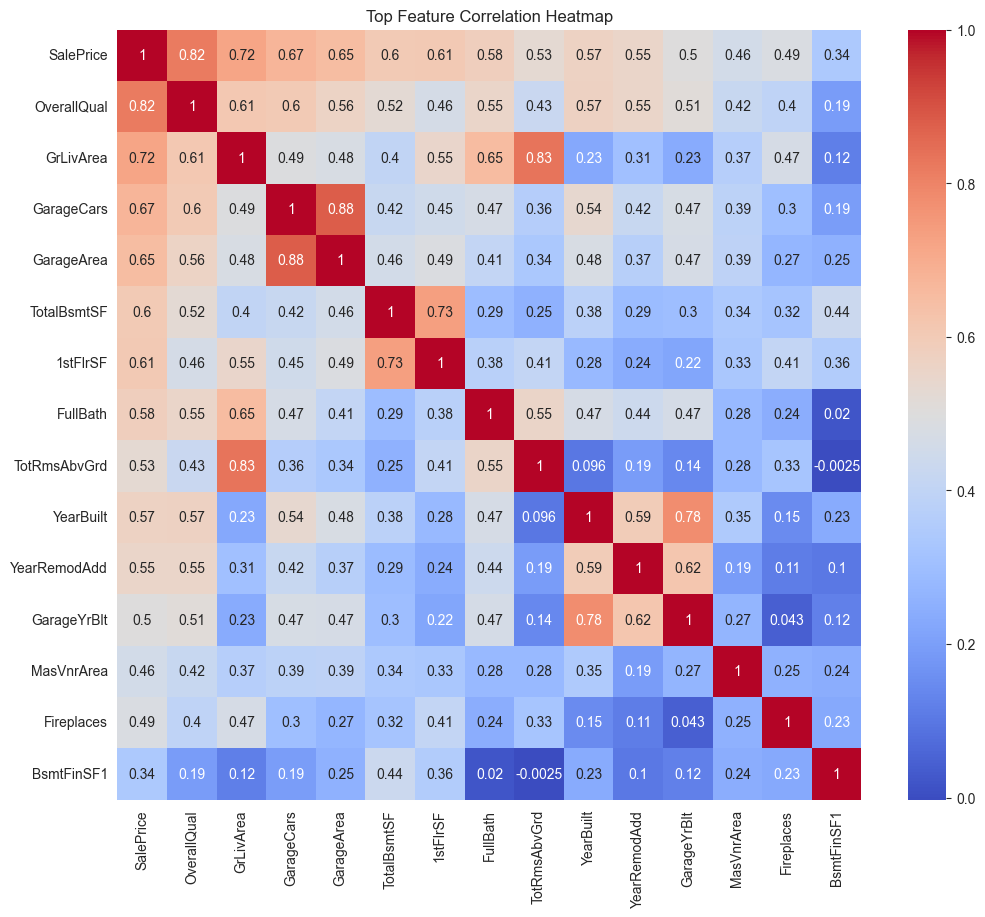

In [14]:
# ============================================
# STEP 14 — Correlation Heatmap
# ============================================

top_features = saleprice_corr.head(15).index

corr_top = scaled_df[top_features].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr_top,
    annot=True,
    cmap='coolwarm'
)

plt.title("Top Feature Correlation Heatmap")

plt.show()

In [15]:
# ============================================
# STEP 15 — Reusable Function
# ============================================

def create_features(dataframe):
    
    dataframe = dataframe.copy()

    dataframe['TotalBathrooms'] = (
        dataframe['FullBath']
        + (0.5 * dataframe['HalfBath'])
        + dataframe['BsmtFullBath']
        + (0.5 * dataframe['BsmtHalfBath'])
    )

    dataframe['HouseAge'] = (
        dataframe['YrSold']
        - dataframe['YearBuilt']
    )

    dataframe['TotalLivingArea'] = (
        dataframe['GrLivArea']
        + dataframe['TotalBsmtSF']
    )

    dataframe['HasGarage'] = (
        dataframe['GarageArea'] > 0
    ).astype(int)

    return dataframe

sample_df = create_features(df)

print("Reusable Function Applied Successfully")

display(sample_df.head())

Reusable Function Applied Successfully


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalBathrooms,HouseAge,RemodelAge,TotalPorchSF,TotalLivingArea,HasGarage,HasBasement,TotalOutdoorArea
0,1,60,RL,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,Gd,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,Gd,MnPrv,Shed,0,2,2008,WD,Normal,208500.0,3.5,5,5,61,2566,1,1,8511
1,2,20,RL,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,BrkFace,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,Gd,MnPrv,Shed,0,5,2007,WD,Normal,181500.0,2.5,31,31,298,2524,1,1,9898
2,3,60,RL,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,Gd,MnPrv,Shed,0,9,2008,WD,Normal,223500.0,3.5,7,6,42,2706,1,1,11292
3,4,70,RL,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,BrkFace,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,Gd,MnPrv,Shed,0,2,2006,WD,Abnorml,140000.0,2.0,91,36,307,2473,1,1,9857
4,5,60,RL,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,Gd,MnPrv,Shed,0,12,2008,WD,Normal,250000.0,3.5,8,8,276,3343,1,1,14536


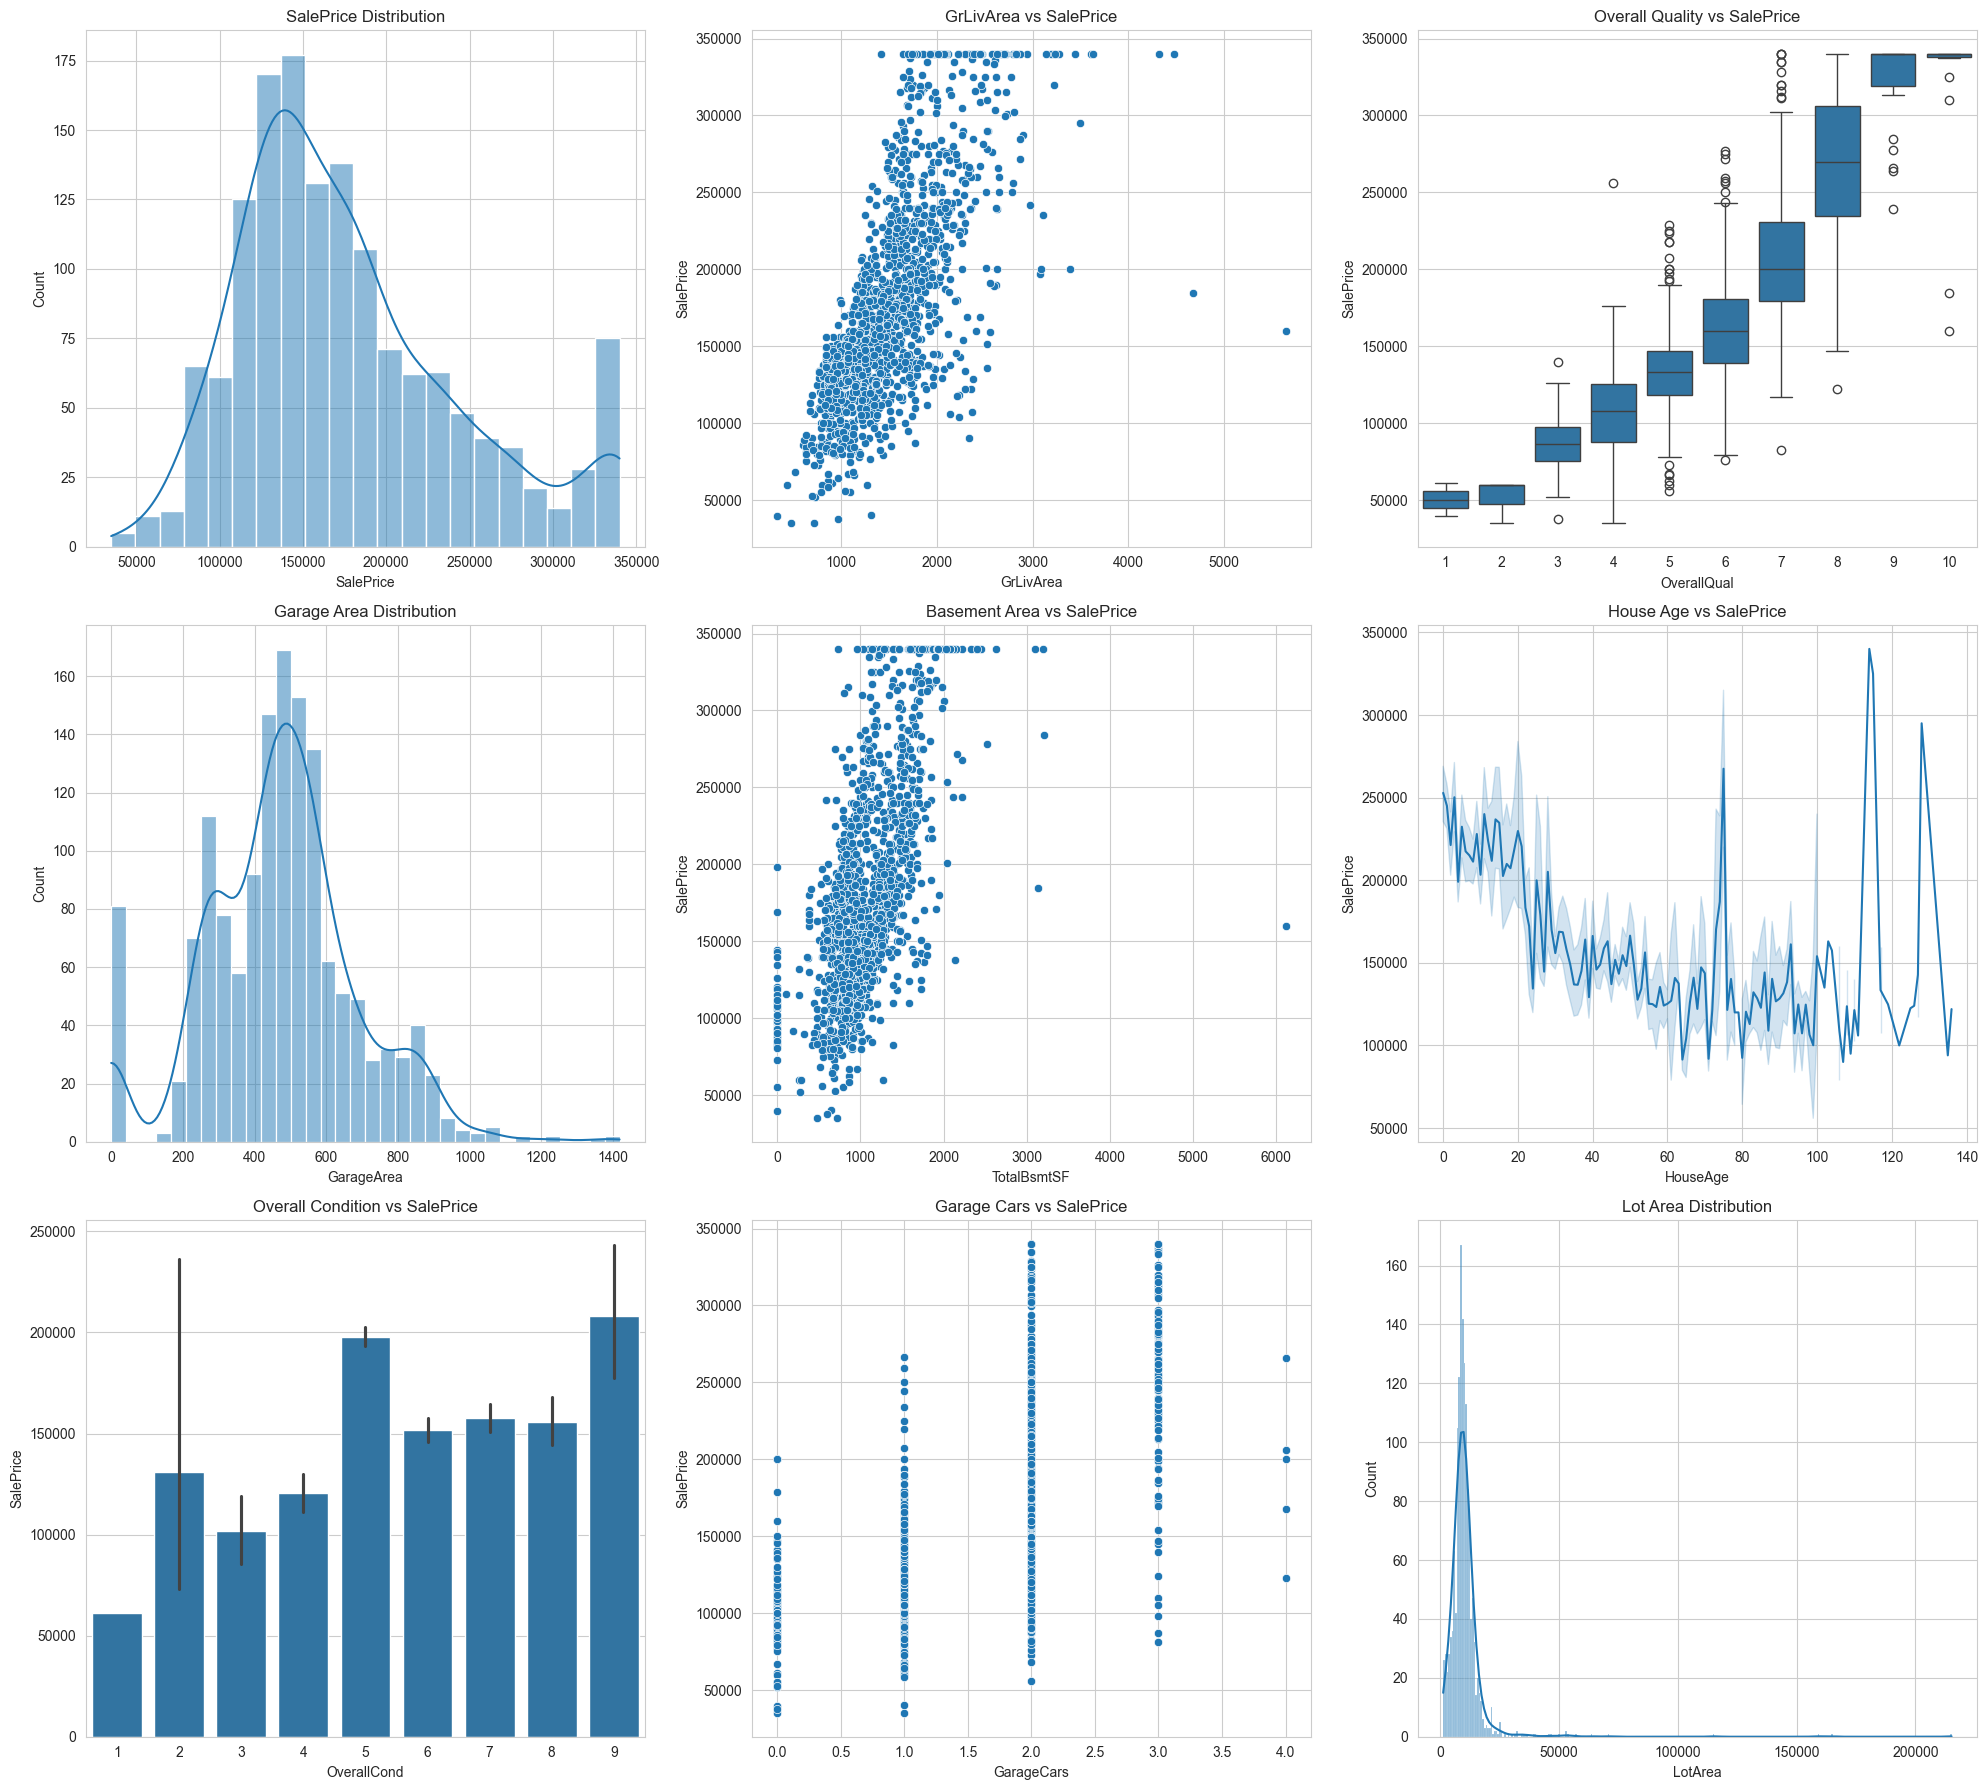

In [16]:
# ============================================
# STEP 16 — Advanced Dashboard
# ============================================

fig, axes = plt.subplots(3,3, figsize=(20,18))

# 1
sns.histplot(
    df['SalePrice'],
    kde=True,
    ax=axes[0,0]
)
axes[0,0].set_title("SalePrice Distribution")

# 2
sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice'],
    ax=axes[0,1]
)
axes[0,1].set_title("GrLivArea vs SalePrice")

# 3
sns.boxplot(
    x=df['OverallQual'],
    y=df['SalePrice'],
    ax=axes[0,2]
)
axes[0,2].set_title("Overall Quality vs SalePrice")

# 4
sns.histplot(
    df['GarageArea'],
    kde=True,
    ax=axes[1,0]
)
axes[1,0].set_title("Garage Area Distribution")

# 5
sns.scatterplot(
    x=df['TotalBsmtSF'],
    y=df['SalePrice'],
    ax=axes[1,1]
)
axes[1,1].set_title("Basement Area vs SalePrice")

# 6
sns.lineplot(
    x=df['HouseAge'],
    y=df['SalePrice'],
    ax=axes[1,2]
)
axes[1,2].set_title("House Age vs SalePrice")

# 7
sns.barplot(
    x=df['OverallCond'],
    y=df['SalePrice'],
    ax=axes[2,0]
)
axes[2,0].set_title("Overall Condition vs SalePrice")

# 8
sns.scatterplot(
    x=df['GarageCars'],
    y=df['SalePrice'],
    ax=axes[2,1]
)
axes[2,1].set_title("Garage Cars vs SalePrice")

# 9
sns.histplot(
    df['LotArea'],
    kde=True,
    ax=axes[2,2]
)
axes[2,2].set_title("Lot Area Distribution")

plt.tight_layout()

plt.savefig("advanced_dashboard.png")

plt.show()

In [17]:
# ============================================
# STEP 17 — Final Dataset Export
# ============================================

scaled_df.to_csv(
    "house_prices_processed.csv",
    index=False
)

print("Processed Dataset Saved Successfully")

Processed Dataset Saved Successfully


In [18]:
# ============================================
# STEP 18 — Final Summary
# ============================================

print("PROJECT SUMMARY")
print("="*50)

print("\nOriginal Dataset Shape:", df.shape)

print("\nProcessed Dataset Shape:", scaled_df.shape)

print("\nTotal Engineered Features:", len(engineered_features))

print("\nTop 5 Important Features:")

display(mi_df.head())

print("\nProject Completed Successfully")

PROJECT SUMMARY

Original Dataset Shape: (1460, 89)

Processed Dataset Shape: (1460, 89)

Total Engineered Features: 8

Top 5 Important Features:


,Feature,MI Score
84,TotalLivingArea,0.650606
17,OverallQual,0.564228
12,Neighborhood,0.533759
46,GrLivArea,0.471493
62,GarageArea,0.368322



Project Completed Successfully


# House Prices Data Analysis Report

---

## 1. Executive Summary

This project focuses on advanced feature engineering and exploratory data analysis (EDA) using the House Prices dataset. The primary objective was to preprocess raw housing data, engineer meaningful features, handle missing values and outliers, and identify the most influential factors affecting house prices.

The analysis was performed using Python libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn. Various visualization and statistical techniques were applied to transform the dataset into a machine-learning-ready format.

## 2. Data Cleaning & Missing Value Handling

The dataset contained several missing values across both numerical and categorical features. Numerical missing values were handled using median imputation, while categorical missing values were filled using mode imputation.

This preprocessing step ensured that the dataset became complete and suitable for further analysis and feature engineering without losing important information.

## 3. Feature Engineering

Multiple new features were engineered to improve the predictive power of the dataset. These features included:

- TotalBathrooms
- HouseAge
- RemodelAge
- TotalPorchSF
- TotalLivingArea
- HasGarage
- HasBasement
- TotalOutdoorArea

Feature engineering helped reveal deeper relationships between property characteristics and house prices.

## 4. Exploratory Data Analysis (EDA)

Exploratory data analysis was performed to understand the distribution and relationships of important variables. Histograms, scatter plots, box plots, and heatmaps were used to visualize patterns within the dataset.

Strong correlations were observed between SalePrice and features such as OverallQual, GrLivArea, GarageCars, and TotalBsmtSF.

## 5. Feature Scaling & Transformation

Categorical variables were encoded using Label Encoding, and numerical features were standardized using StandardScaler.

Skewness analysis was also performed, and highly skewed features were transformed using logarithmic transformation to improve distribution consistency and model compatibility.

## 6. Feature Importance Analysis

Mutual Information Regression was used to identify the most important features affecting SalePrice. The analysis showed that overall house quality, living area, garage capacity, and total basement area were among the strongest predictors of house prices.

This step helped in understanding which variables contribute most significantly to the target variable.

## 7. Dashboard & Visualization Summary

An advanced dashboard was created containing multiple visualizations, including:

- SalePrice distribution
- Living area vs SalePrice
- Quality vs SalePrice
- Garage analysis
- Basement analysis
- House age trends

These visualizations provided a comprehensive overview of the dataset and highlighted important trends and relationships.

## 8. Reflection

This project provided hands-on experience in advanced data preprocessing, feature engineering, and exploratory data analysis using real-world housing data.

I learned how to handle missing values, treat outliers, perform encoding and scaling, analyze feature importance, and build professional visualizations. This project also improved my understanding of preparing datasets for machine learning workflows.